In [1]:
from edn_popdyn.paths import POP_MAT_ROOT, PCA_ROOT

# 0.2 — Batch PCA on population activity

Fit per-recording PCA on the POP_MAT arrays, choose n_pcs across the dataset with population QC, and save PCA latents + reaction times.

In [2]:
import os
import sys
import glob
import pickle
import datetime
import warnings
import re

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

### Configuration

`min_units` (the population QC threshold) is the only knob with real interpretive consequences. We default to 10 simultaneously recorded units as a hard floor.

`var_threshold` is the cumulative variance fraction used in dimensionality selection

In [3]:
area               = 'ALL'
min_units          = 10
var_threshold      = 0.90
dim_selection_rule = 'participation_ratio'

base_dir        = str(PROCESSED_DATA_DIR / "pop_mats")
output_base_dir = str(PROCESSED_DATA_DIR / "pca_data")

os.makedirs(output_base_dir, exist_ok=True)
print('Input :', base_dir)
print('Output:', output_base_dir)
print(f'Population QC: minimum {min_units} units')
print(f'Dim selection: {dim_selection_rule} of per-recording PCs needed for {var_threshold*100:.0f}% variance')

Input : /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pop_mats
Output: /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca
Population QC: minimum 10 units
Dim selection: participation_ratio of per-recording PCs needed for 90% variance


### Helpers — load, fit, diagnostic plot

`participation_ratio(eigenvalues) = (Σλ)² / Σλ²`. Standard
effective dimensionality measure: summarizes how many directions the variance
is spread across

In [4]:
def load_pop_mat_and_rt(bird_dir):
    pkl_files = sorted(
        f for f in os.listdir(bird_dir)
        if f.endswith('.pkl') and not f.endswith('_rt.pkl')
    )
    if not pkl_files:
        raise ValueError(f'No .pkl files in {bird_dir}')

    Z_dict, rt_dict = {}, {}
    for fname in pkl_files:
        key = fname.replace('.pkl', '')
        with open(os.path.join(bird_dir, fname), 'rb') as fh:
            Z = pickle.load(fh)

        if Z.ndim == 3:
            Z = np.transpose(Z, (0, 2, 1))
        Z_dict[key] = Z
        rt_path = os.path.join(bird_dir, f'{key}_rt.pkl')
        if os.path.exists(rt_path):
            with open(rt_path, 'rb') as fh:
                rt_dict[key] = pickle.load(fh)
        else:
            rt_dict[key] = np.full(Z.shape[0], np.nan)
    return Z_dict, rt_dict

def participation_ratio(eigenvalues):

    eigenvalues = np.asarray(eigenvalues, dtype=float)
    if not np.any(eigenvalues > 0):
        return np.nan
    return float((eigenvalues.sum() ** 2) / np.sum(eigenvalues ** 2))

def fit_pca_full(Z_dict):

    chunks = []
    for Z in Z_dict.values():
        n_trials, n_timebins, n_neurons = Z.shape
        chunks.append(Z.reshape(n_trials * n_timebins, n_neurons))
    fit_data = np.concatenate(chunks, axis=0)
    n_components = min(fit_data.shape)
    pca = PCA(n_components=n_components)
    pca.fit(fit_data)
    return pca, fit_data

def project_with_pca(Z_dict, pca, n_pcs):

    actual_pcs = min(n_pcs, pca.n_components_)
    components = pca.components_[:actual_pcs]
    mean_      = pca.mean_
    out = {}
    for key, Z in Z_dict.items():
        n_trials, n_timebins, n_neurons = Z.shape
        flat = Z.reshape(n_trials * n_timebins, n_neurons) - mean_
        proj = flat @ components.T
        out[key] = proj.reshape(n_trials, n_timebins, actual_pcs)
    return out, actual_pcs

def plot_variance_explained(pca, output_path, n_pcs_chosen, title=''):
    fig, ax = plt.subplots(figsize=(5, 3))
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar, 'o-')
    ax.axhline(var_threshold * 100, color='gray', linestyle='--', lw=0.8,
               label=f'{var_threshold*100:.0f}%')
    ax.axvline(n_pcs_chosen, color='C3', linestyle='--', lw=0.8,
               label=f'n_pcs = {n_pcs_chosen}')
    ax.set_xlabel('PC')
    ax.set_ylabel('Cumulative variance explained (%)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(output_path, 'pca_variance_explained.png'), dpi=120)
    plt.close(fig)

### Pass 1 — fit per-recording PCA with all components, collect dimensionality stats

Fit PCA without truncating, and record
- the full cumulative variance curve,
- the smallest `k` such that cumulative variance ≥ `var_threshold`,
- the participation ratio,
- the population size and total trial count,
- whether it would pass the population QC 

In [5]:
def enumerate_recordings(base_dir):
    tasks = []
    for bird_str in sorted(os.listdir(base_dir)):
        bird_path = os.path.join(base_dir, bird_str)
        if not os.path.isdir(bird_path):
            continue
        for rec_str in sorted(os.listdir(bird_path)):
            if os.path.isdir(os.path.join(bird_path, rec_str)):
                tasks.append((bird_str, rec_str))
    return tasks

tasks = enumerate_recordings(base_dir)
print(f'Found {len(tasks)} candidate recordings\n')

pass1_rows         = []
fitted_models      = {}
excluded_rows      = []

for bird_str, rec_str in tqdm(tasks, desc='pass 1: fit + measure'):
    bird_dir = os.path.join(base_dir, bird_str, rec_str)
    try:
        Z_dict, rt_dict = load_pop_mat_and_rt(bird_dir)
    except Exception as e:
        excluded_rows.append({'bird': bird_str, 'rec': rec_str,
                              'reason': f'load_error: {e}', 'n_units': None})
        continue

    n_neurons = list(Z_dict.values())[0].shape[2]
    n_trials  = sum(Z.shape[0] for Z in Z_dict.values())

    if n_neurons < min_units:
        excluded_rows.append({'bird': bird_str, 'rec': rec_str,
                              'reason': f'n_units={n_neurons} < min_units={min_units}',
                              'n_units': n_neurons})
        continue

    try:
        pca, _ = fit_pca_full(Z_dict)
    except Exception as e:
        excluded_rows.append({'bird': bird_str, 'rec': rec_str,
                              'reason': f'pca_error: {e}', 'n_units': n_neurons})
        continue

    cumvar      = np.cumsum(pca.explained_variance_ratio_)
    pcs_for_th  = int(np.searchsorted(cumvar, var_threshold)) + 1
    pr          = participation_ratio(pca.explained_variance_)

    pass1_rows.append({
        'bird': bird_str, 'rec': rec_str,
        'n_units': n_neurons, 'n_trials': n_trials,
        'n_conditions': len(Z_dict),
        f'pcs_for_{int(var_threshold*100)}pct': pcs_for_th,
        'participation_ratio': pr,
        'pcs_total_available': pca.n_components_,
    })
    fitted_models[(bird_str, rec_str)] = (pca, Z_dict, rt_dict)

df_pass1 = pd.DataFrame(pass1_rows)
df_excluded = pd.DataFrame(excluded_rows)
print(f'\nKept {len(df_pass1)} recordings, excluded {len(df_excluded)}')
df_pass1.head()

Found 355 candidate recordings



pass 1: fit + measure: 100%|██████████████████| 355/355 [14:11<00:00,  2.40s/it]


Kept 344 recordings, excluded 11


,bird,rec,n_units,n_trials,n_conditions,pcs_for_90pct,participation_ratio,pcs_total_available
0,B1170,exp1_rec1_dat2021-04-08_18-57-54_800,46,4079,12,19,10.756534,46
1,B1170,exp1_rec1_dat2021-04-09_08-07-32_800,26,430,52,11,7.768508,26
2,B1170,exp1_rec1_dat2021-04-09_11-56-08_800,65,5891,53,22,12.545023,65
3,B1170,exp1_rec1_dat2021-04-09_23-19-54_800,95,250,22,27,10.790556,95
4,B1170,exp1_rec1_dat2021-04-10_08-04-30_800,70,6859,76,23,12.054451,70


### Choose `n_pcs` for the whole dataset

Two manuscript-defensible numbers fall out of pass 1:

1. **Variance-threshold rule.** Median `n_pcs = ceil( median across recordings of "PCs needed to reach var_threshold" )`
2. **Participation ratio.** Reported alongside the variance rule 

Report **both** in the manuscript and use the variance-threshold number for the actual analysis 

Dim selection: rounded median PR = 8.59 -> n_pcs = 9
  (mean PR across recordings: 9.15)
Across 344 recordings:
  PCs to reach 90% variance: median=20.0, mean=20.47, min=2, max=60
  Participation ratio (effective dimensionality): median=8.59, mean=9.15, min=1.88, max=21.17

>>> n_pcs chosen for the dataset: 9  (rule: participation_ratio of pcs_for_90pct)

Wrote /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca/dim_selection_summary.csv


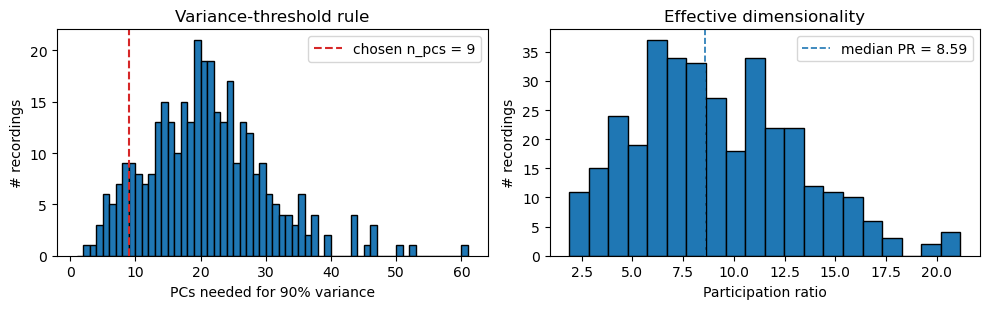

In [6]:
pcs_col = f'pcs_for_{int(var_threshold*100)}pct'

if dim_selection_rule == 'participation_ratio':
    pr_med = df_pass1['participation_ratio'].median()
    pr_mean = df_pass1['participation_ratio'].mean()
    n_pcs_chosen = int(round(pr_med))
    print(f'Dim selection: rounded median PR = {pr_med:.2f} -> n_pcs = {n_pcs_chosen}')
    print(f'  (mean PR across recordings: {pr_mean:.2f})')
elif dim_selection_rule == 'median':
    n_pcs_chosen = int(np.ceil(df_pass1[pcs_col].median()))
elif dim_selection_rule == 'mean':
    n_pcs_chosen = int(np.ceil(df_pass1[pcs_col].mean()))
else:
    raise ValueError(dim_selection_rule)

print(f'Across {len(df_pass1)} recordings:')
print(f'  PCs to reach {var_threshold*100:.0f}% variance: '
      f'median={df_pass1[pcs_col].median():.1f}, '
      f'mean={df_pass1[pcs_col].mean():.2f}, '
      f'min={df_pass1[pcs_col].min()}, '
      f'max={df_pass1[pcs_col].max()}')
print(f'  Participation ratio (effective dimensionality): '
      f'median={df_pass1["participation_ratio"].median():.2f}, '
      f'mean={df_pass1["participation_ratio"].mean():.2f}, '
      f'min={df_pass1["participation_ratio"].min():.2f}, '
      f'max={df_pass1["participation_ratio"].max():.2f}')
print(f'\n>>> n_pcs chosen for the dataset: {n_pcs_chosen}  '
      f'(rule: {dim_selection_rule} of {pcs_col})')

summary_csv = os.path.join(output_base_dir, 'dim_selection_summary.csv')
df_pass1.to_csv(summary_csv, index=False)
print(f'\nWrote {summary_csv}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(df_pass1[pcs_col], bins=range(1, df_pass1[pcs_col].max()+2), edgecolor='black')
ax[0].axvline(n_pcs_chosen, color='C3', linestyle='--', lw=1.5,
              label=f'chosen n_pcs = {n_pcs_chosen}')
ax[0].set_xlabel(f'PCs needed for {var_threshold*100:.0f}% variance')
ax[0].set_ylabel('# recordings')
ax[0].set_title('Variance-threshold rule')
ax[0].legend()
ax[1].hist(df_pass1['participation_ratio'].dropna(), bins=20, edgecolor='black')
ax[1].axvline(df_pass1['participation_ratio'].median(),
              color='C0', linestyle='--', lw=1.2,
              label=f'median PR = {df_pass1["participation_ratio"].median():.2f}')
ax[1].set_xlabel('Participation ratio')
ax[1].set_ylabel('# recordings')
ax[1].set_title('Effective dimensionality')
ax[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(output_base_dir, 'dim_selection_summary.png'), dpi=120)
plt.show()

### Population QC — what was excluded and why

In [7]:
if len(df_excluded) == 0:
    print('No recordings excluded.')
else:
    excl_csv = os.path.join(output_base_dir, 'excluded_recordings.csv')
    df_excluded.to_csv(excl_csv, index=False)
    print(f'{len(df_excluded)} recordings excluded — saved to {excl_csv}\n')
    pop_qc = df_excluded[df_excluded['reason'].str.startswith('n_units=', na=False)]
    other  = df_excluded[~df_excluded['reason'].str.startswith('n_units=', na=False)]
    print(f'  {len(pop_qc)} dropped by population QC (n_units < {min_units})')
    print(f'  {len(other)} dropped for other reasons (load/PCA errors)')
    print()
    print(df_excluded.to_string(index=False))

11 recordings excluded — saved to /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pca/excluded_recordings.csv

  7 dropped by population QC (n_units < 10)
  4 dropped for other reasons (load/PCA errors)

 bird                                   rec                                                                                                                                  reason  n_units
B1170  exp1_rec1_dat2021-04-14_22-01-13_900 load_error: No .pkl files in /mnt/cube/jugorman/EDNpopdyn/for_github/processed_data/pop_mats/B1170/exp1_rec1_dat2021-04-14_22-01-13_900      NaN
B1188 exp1_rec1_dat2020-11-15_09-14-51_2250                                                                                                                n_units=6 < min_units=10      6.0
B1188 exp4_rec1_dat2020-11-14_10-55-55_2250                                                                                                                n_units=9 < min_units=10      9.0
B1248  exp1_rec1_dat2021-07-09_23

### Pass 2 — project, save outputs at the chosen `n_pcs`


In [8]:
saved_records = []
for (bird_str, rec_str), (pca, Z_dict, rt_dict) in tqdm(
        fitted_models.items(), desc='pass 2: project + save'):
    output_dir = os.path.join(output_base_dir, bird_str, rec_str)
    os.makedirs(output_dir, exist_ok=True)

    pca_dict, actual_pcs = project_with_pca(Z_dict, pca, n_pcs_chosen)

    pca_save = PCA(n_components=actual_pcs)
    pca_save.components_              = pca.components_[:actual_pcs].copy()
    pca_save.explained_variance_      = pca.explained_variance_[:actual_pcs].copy()
    pca_save.explained_variance_ratio_ = pca.explained_variance_ratio_[:actual_pcs].copy()
    pca_save.singular_values_         = pca.singular_values_[:actual_pcs].copy()
    pca_save.mean_                    = pca.mean_.copy()
    pca_save.n_components_            = actual_pcs
    pca_save.n_features_in_           = pca.n_features_in_
    pca_save.noise_variance_          = pca.noise_variance_

    with open(os.path.join(output_dir, 'trial_type_dict_pca.pkl'), 'wb') as fh:
        pickle.dump(pca_dict, fh)
    with open(os.path.join(output_dir, 'trial_type_rt_dict.pkl'), 'wb') as fh:
        pickle.dump(rt_dict, fh)
    with open(os.path.join(output_dir, 'pca_model.pkl'), 'wb') as fh:
        pickle.dump(pca_save, fh)

    plot_variance_explained(
        pca, output_dir, actual_pcs,
        title=f'{bird_str} / {rec_str}  ({sum(Z.shape[0] for Z in Z_dict.values())} trials)'
    )

    saved_records.append({
        'bird': bird_str, 'rec': rec_str,
        'n_units': list(Z_dict.values())[0].shape[2],
        'n_trials': sum(Z.shape[0] for Z in Z_dict.values()),
        'n_conditions': len(Z_dict),
        'n_pcs': actual_pcs,
    })

df_saved = pd.DataFrame(saved_records)
print(f'\nSaved {len(df_saved)} recordings at n_pcs={n_pcs_chosen}')
df_saved.head()

pass 2: project + save: 100%|█████████████████| 344/344 [03:02<00:00,  1.88it/s]


Saved 344 recordings at n_pcs=9


,bird,rec,n_units,n_trials,n_conditions,n_pcs
0,B1170,exp1_rec1_dat2021-04-08_18-57-54_800,46,4079,12,9
1,B1170,exp1_rec1_dat2021-04-09_08-07-32_800,26,430,52,9
2,B1170,exp1_rec1_dat2021-04-09_11-56-08_800,65,5891,53,9
3,B1170,exp1_rec1_dat2021-04-09_23-19-54_800,95,250,22,9
4,B1170,exp1_rec1_dat2021-04-10_08-04-30_800,70,6859,76,9


### Manuscript summary statistics

In [9]:
all_keys = set()
for (_, _), (_, Z_dict, _) in fitted_models.items():
    all_keys.update(Z_dict.keys())
all_keys = sorted(all_keys)

tokenized = [k.split('_') for k in all_keys]
max_len = max(len(t) for t in tokenized)
print(f'{len(all_keys)} unique condition keys, max {max_len} underscore-separated tokens')
for i in range(max_len):
    toks = sorted({t[i] for t in tokenized if i < len(t)})
    print(f'  slot {i}: {toks}')

ACTIVE_PAT   = re.compile(r'_active$',  re.IGNORECASE)
PASSIVE_PAT  = re.compile(r'_passive$', re.IGNORECASE)

def is_active(key):  return bool(ACTIVE_PAT.search(key))
def is_passive(key): return bool(PASSIVE_PAT.search(key))

def is_no_cue(key):
    toks = key.split('_')
    return ('NC' in toks) or ('nocue' in [t.lower() for t in toks])

def is_valid(key):
    toks = key.split('_')
    lower = [t.lower() for t in toks]
    return ('V' in toks) or ('valid' in lower)

def is_invalid(key):
    toks = key.split('_')
    lower = [t.lower() for t in toks]
    return ('I' in toks) or ('invalid' in lower)

print('\nSample classification:')
for k in all_keys[:10]:
    print(f'  {k!r:50s}  active={is_active(k):d}  passive={is_passive(k):d}  '
          f'NC={is_no_cue(k):d}  V={is_valid(k):d}  I={is_invalid(k):d}')

312 unique condition keys, max 6 underscore-separated tokens
  slot 0: ['sL', 'sR', 'wL', 'wR']
  slot 1: ['AE', 'AF', 'AG', 'AH', 'BE', 'BF', 'BG', 'BH', 'CE', 'CF', 'CG', 'CH', 'DE', 'DF', 'DG', 'DH']
  slot 2: ['Z']
  slot 3: ['NC', 'invalid', 'valid']
  slot 4: ['correct', 'incorrect', 'passive']
  slot 5: ['active']

Sample classification:
  'sL_AE_Z_NC_correct_active'                         active=1  passive=0  NC=1  V=0  I=0
  'sL_AE_Z_NC_incorrect_active'                       active=1  passive=0  NC=1  V=0  I=0
  'sL_AE_Z_NC_passive'                                active=0  passive=1  NC=1  V=0  I=0
  'sL_AE_Z_invalid_correct_active'                    active=1  passive=0  NC=0  V=0  I=1
  'sL_AE_Z_invalid_incorrect_active'                  active=1  passive=0  NC=0  V=0  I=1
  'sL_AE_Z_invalid_passive'                           active=0  passive=1  NC=0  V=0  I=1
  'sL_AE_Z_valid_correct_active'                      active=1  passive=0  NC=0  V=1  I=0
  'sL_AE_Z_valid_incorr

In [10]:
n_total      = 0
n_active     = 0
n_passive    = 0
n_no_cue     = 0
n_valid      = 0
n_invalid    = 0
unit_counts  = []

for (_, _), (_, Z_dict, _) in fitted_models.items():
    unit_counts.append(list(Z_dict.values())[0].shape[2])
    for key, Z in Z_dict.items():
        n = Z.shape[0]
        n_total += n
        if is_active(key):  n_active  += n
        if is_passive(key): n_passive += n
        if is_no_cue(key):  n_no_cue  += n
        if is_valid(key):   n_valid   += n
        if is_invalid(key): n_invalid += n

unit_counts = np.array(unit_counts)

print('=' * 60)
print('  Kept recordings  ')
print('=' * 60)
print(f'  recordings included          : {len(fitted_models)}')
print(f'  recordings excluded          : {len(df_excluded)}')
print(f'  n_pcs (chosen for dataset)   : {n_pcs_chosen}')
print()
print(f'  total trials                 : {n_total}')
print(f'  active trials                : {n_active}')
print(f'  passive trials               : {n_passive}')
print(f'  no-cue trials                : {n_no_cue}')
print(f'  valid trials                 : {n_valid}')
print(f'  invalid trials               : {n_invalid}')
print()
if len(unit_counts):
    print(f'  neural population size range : '
          f'{unit_counts.min()} – {unit_counts.max()} units '
          f'(median {int(np.median(unit_counts))}, mean {unit_counts.mean():.1f})')
print('=' * 60)

  Kept recordings  
  recordings included          : 344
  recordings excluded          : 11
  n_pcs (chosen for dataset)   : 9

  total trials                 : 1047711
  active trials                : 231326
  passive trials               : 816385
  no-cue trials                : 736854
  valid trials                 : 208442
  invalid trials               : 102415

  neural population size range : 10 – 346 units (median 76, mean 87.0)
